In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
data=pd.read_csv('delhivery_data.csv')

In [107]:
data.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


#### Data Pre-Processing & Exploratory Data Analysis

In [108]:
data.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.000000,144867.00000,144867.000000
mean,961.262986,232.926567,234.073372,416.927527,213.868272,284.771297,2.120107,36.196111,18.507548,22.82902,2.218368
std,1037.012769,344.755577,344.990009,598.103621,308.011085,421.119294,1.715421,53.571158,14.775960,17.86066,4.847530
min,20.000000,9.000000,9.000045,9.000000,6.000000,9.008200,0.144000,-244.000000,0.000000,0.00000,-23.444444
25%,161.000000,22.000000,23.355874,51.000000,27.000000,29.914700,1.604264,20.000000,11.000000,12.07010,1.347826
50%,449.000000,66.000000,66.126571,132.000000,64.000000,78.525800,1.857143,29.000000,17.000000,23.51300,1.684211
75%,1634.000000,286.000000,286.708875,513.000000,257.000000,343.193250,2.213483,40.000000,22.000000,27.81325,2.250000
max,7898.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,3051.000000,1611.000000,2191.40370,574.250000


In [109]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

In [110]:
data.isna().sum()

data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64

In [111]:
data['source_name'].fillna(method='ffill', inplace=True)
data['destination_name'].fillna(method='ffill', inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_780\4008280313.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['source_name'].fillna(method='ffill', inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_780\4008280313.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['destination_name'].fillna(method='ffill', inplace=True)


In [112]:
data.isna().sum()

data                              0
trip_creation_time                0
route_schedule_uuid               0
route_type                        0
trip_uuid                         0
source_center                     0
source_name                       0
destination_center                0
destination_name                  0
od_start_time                     0
od_end_time                       0
start_scan_to_end_scan            0
is_cutoff                         0
cutoff_factor                     0
cutoff_timestamp                  0
actual_distance_to_destination    0
actual_time                       0
osrm_time                         0
osrm_distance                     0
factor                            0
segment_actual_time               0
segment_osrm_time                 0
segment_osrm_distance             0
segment_factor                    0
dtype: int64

### Typecasting for the datatypes

In [113]:
# Convert columns to datetime
data['trip_creation_time'] = pd.to_datetime(data['trip_creation_time'], errors='coerce')
data['od_start_time'] = pd.to_datetime(data['od_start_time'], errors='coerce')
data['od_end_time'] = pd.to_datetime(data['od_end_time'], errors='coerce')
data['cutoff_timestamp'] = pd.to_datetime(data['cutoff_timestamp'], errors='coerce')
data['data']=data['data'].astype('category')
data['route_type']=data['route_type'].astype('category')

In [114]:
# Check for duplicates
duplicates=data.duplicated()
print(duplicates.sum())

0


There are no duplicates in the dataset. The rows with null values have been removed. The features are typecasted.

##### Extracting source and destination details from source_name and destination_name respectively.

In [115]:
# Splitting the destination_name and source_name column into city-place-code-State
pattern = r'([^_]+)_?([^_]+)?_?([^_]+)? \(([^)]+)\)'
# Apply the extraction to your columns
data[['source_city', 'source_place', 'source_code', 'source_state']] = data['source_name'].str.extract(pattern)
data[['destination_city', 'destination_place', 'destination_code', 'destination_state']] = data['destination_name'].str.extract(pattern)

In [116]:
data['trip_year'] = data['trip_creation_time'].dt.year
data['trip_month'] = data['trip_creation_time'].dt.month
data['trip_day'] = data['trip_creation_time'].dt.day

In [117]:
data['trip_time'] = (data['od_end_time'] - data['od_start_time']).dt.total_seconds() / 60
data.drop(columns=['od_start_time','od_end_time'],inplace=True) 

In [118]:
data.drop(columns=['source_name','destination_name'],inplace=True)

There are few unknown columns in the dataset. We can check their relevance using corr() and drop them accordingly.

In [119]:
# Select integer,float and bool columns
numerical_cols = data.select_dtypes(include=['int64', 'float64','bool']).columns
numerical_data = data[numerical_cols]
# Compute correlation matrix for integer and float columns
correlation_matrix = numerical_data.corr()
correlation_matrix

,start_scan_to_end_scan,is_cutoff,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,trip_time
start_scan_to_end_scan,1.000000,0.299099,0.784673,0.785006,0.785937,0.785298,0.784138,-0.023193,0.093301,0.219848,0.306983,-0.020227,1.000000
is_cutoff,0.299099,1.000000,0.190815,0.191571,0.168265,0.186484,0.188245,-0.121386,-0.007042,0.216321,0.254645,-0.106569,0.299098
cutoff_factor,0.784673,0.190815,1.000000,0.999986,0.978720,0.995833,0.997116,-0.064551,0.044986,0.157936,0.231106,-0.031452,0.784673
actual_distance_to_destination,0.785006,0.191571,0.999986,1.000000,0.978659,0.995872,0.997149,-0.064736,0.045241,0.158832,0.232119,-0.031603,0.785005
actual_time,0.785937,0.168265,0.978720,0.978659,1.000000,0.977998,0.979399,0.033502,0.124411,0.171465,0.242282,0.017558,0.785936
osrm_time,0.785298,0.186484,0.995833,0.995872,0.977998,1.000000,0.999119,-0.069074,0.049892,0.177066,0.242282,-0.033057,0.785298
osrm_distance,0.784138,0.188245,0.997116,0.997149,0.979399,0.999119,1.000000,-0.065384,0.048705,0.169151,0.239669,-0.031805,0.784137
factor,-0.023193,-0.121386,-0.064551,-0.064736,0.033502,-0.069074,-0.065384,1.000000,0.518388,-0.053187,-0.036761,0.540403,-0.023193
segment_actual_time,0.093301,-0.007042,0.044986,0.045241,0.124411,0.049892,0.048705,0.518388,1.000000,0.433422,0.448959,0.483864,0.093302
segment_osrm_time,0.219848,0.216321,0.157936,0.158832,0.171465,0.177066,0.169151,-0.053187,0.433422,1.000000,0.948523,-0.068447,0.219846


We can see that is_cutoff,factor,segment_factor have very low correlation values. At the same time cutoff_factor and cutoff_timestamp is not useful from business perspective. Hence we can drop these columns from the dataset for further processing.

In [120]:
data.drop(columns=['is_cutoff','cutoff_factor','cutoff_timestamp','factor','segment_factor'],inplace=True)

#### Grouping and Aggregation of rows on trip_uuid,source_centre and destination_centre

In [121]:
group_features=['trip_uuid','source_center','destination_center']

In [122]:
data_agg = data.groupby(group_features).agg({
    'data': 'first',
    'route_type': 'first',
    'start_scan_to_end_scan': 'first',
    'actual_distance_to_destination': 'last',
    'actual_time': 'last',
    'osrm_time': 'last',
    'osrm_distance': 'last',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum',
    'source_city': 'first',
    'source_place': 'first',
    'source_state': 'first',
    'destination_city': 'first',
    'destination_place': 'first',
    'destination_state': 'first',
    'trip_year': 'first',
    'trip_month': 'first',
    'trip_day': 'first',
    'trip_time': 'first'
}).reset_index()


In [123]:
data_agg.iloc[0]

trip_uuid                         trip-153671041653548748
source_center                                IND209304AAA
destination_center                           IND000000ACB
data                                             training
route_type                                            FTL
start_scan_to_end_scan                             1260.0
actual_distance_to_destination                 383.759164
actual_time                                         732.0
osrm_time                                           329.0
osrm_distance                                    446.5496
segment_actual_time                                 728.0
segment_osrm_time                                   534.0
segment_osrm_distance                            670.6205
source_city                                       Central
source_place                                            H
source_state                                Uttar Pradesh
destination_city                                  Gurgaon
destination_pl

In [124]:
data_agg.iloc[1]

trip_uuid                         trip-153671041653548748
source_center                                IND462022AAA
destination_center                           IND209304AAA
data                                             training
route_type                                            FTL
start_scan_to_end_scan                              999.0
actual_distance_to_destination                 440.973689
actual_time                                         830.0
osrm_time                                           388.0
osrm_distance                                    544.8027
segment_actual_time                                 820.0
segment_osrm_time                                   474.0
segment_osrm_distance                            649.8528
source_city                                        Bhopal
source_place                                     Trnsport
source_state                               Madhya Pradesh
destination_city                                  Central
destination_pl

In [125]:
data_agg_1 =data_agg.copy()

In [126]:
data_agg_final=data_agg.groupby('trip_uuid').agg({
    'source_center':'first',
    'destination_center':'first',
    'route_type' : 'first',
    'start_scan_to_end_scan': 'first',
    'actual_distance_to_destination': 'last',
    'actual_time': 'first',
    'osrm_time': 'sum',
    'osrm_distance': 'last',
    'segment_actual_time': 'sum',
    'segment_osrm_time': 'sum',
    'segment_osrm_distance': 'sum',
    'source_city': 'first',
    'source_place': 'first',
    'source_state': 'first',
    'destination_city': 'first',
    'destination_place': 'first',
    'destination_state': 'first',
    'trip_year': 'first',
    'trip_month': 'first',
    'trip_day': 'first',
    'trip_time': 'first'}).reset_index()


In [127]:
data_agg_final.iloc[0]

trip_uuid                         trip-153671041653548748
source_center                                IND209304AAA
destination_center                           IND000000ACB
route_type                                            FTL
start_scan_to_end_scan                             1260.0
actual_distance_to_destination                 440.973689
actual_time                                         732.0
osrm_time                                           717.0
osrm_distance                                    544.8027
segment_actual_time                                1548.0
segment_osrm_time                                  1008.0
segment_osrm_distance                           1320.4733
source_city                                       Central
source_place                                            H
source_state                                Uttar Pradesh
destination_city                                  Gurgaon
destination_place                                Bilaspur
destination_st

#### Visual Analysis

a. Inter and Intra-State Trips

In [128]:
# Group by 'source_state' and 'destination_state' and get the count of occurrences
state_combi_counts = data_agg_final.groupby(['source_state', 'destination_state']).size().reset_index(name='count')
# Filter to keep only combinations where source_state and destination_state are same
intra_state_combinations = state_combi_counts[state_combi_counts['source_state'] == state_combi_counts['destination_state']].reset_index(drop=True)
sorted_intra_state_combinations = intra_state_combinations.sort_values(by='count', ascending=False).reset_index(drop=True)
# Filter to keep only combinations where source_state and destination_state are different
inter_state_combinations = state_combi_counts[state_combi_counts['source_state'] != state_combi_counts['destination_state']].reset_index(drop=True)
sorted_inter_state_combinations = inter_state_combinations.sort_values(by='count', ascending=False).reset_index(drop=True)


In [129]:
sorted_intra_state_combinations

,source_state,destination_state,count
0,Maharashtra,Maharashtra,2459
1,Karnataka,Karnataka,2040
2,Tamil Nadu,Tamil Nadu,1005
3,Haryana,Haryana,805
4,Gujarat,Gujarat,686
5,Telangana,Telangana,672
6,West Bengal,West Bengal,610
7,Uttar Pradesh,Uttar Pradesh,574
8,Rajasthan,Rajasthan,442
9,Punjab,Punjab,399


In [130]:
sorted_inter_state_combinations

,source_state,destination_state,count
0,Delhi,Haryana,386
1,Haryana,Delhi,308
2,Haryana,Uttar Pradesh,141
3,Delhi,Uttar Pradesh,111
4,Haryana,Punjab,105
...,...,...,...
117,Maharashtra,Punjab,1
118,Punjab,Maharashtra,1
119,Punjab,Karnataka,1
120,Maharashtra,Uttar Pradesh,1


These two tables give us count of shipments/trips inter and intra state.

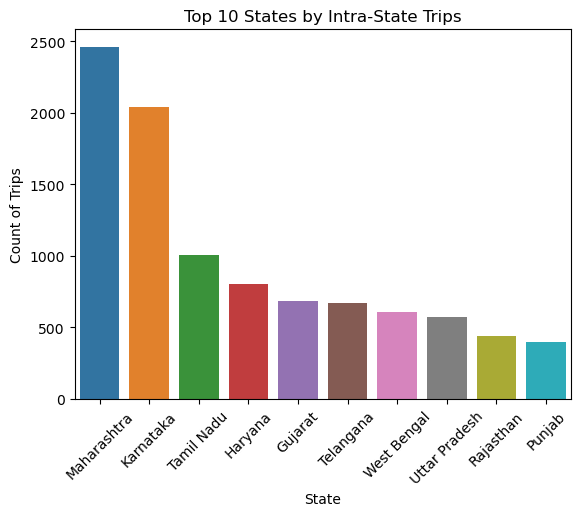

In [131]:
sns.barplot(data=sorted_intra_state_combinations[0:10],x='source_state',y='count')
plt.title('Top 10 States by Intra-State Trips')
plt.xlabel('State')
plt.ylabel('Count of Trips')
plt.xticks(rotation =45)
plt.show()

b. Route type

F:\Anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


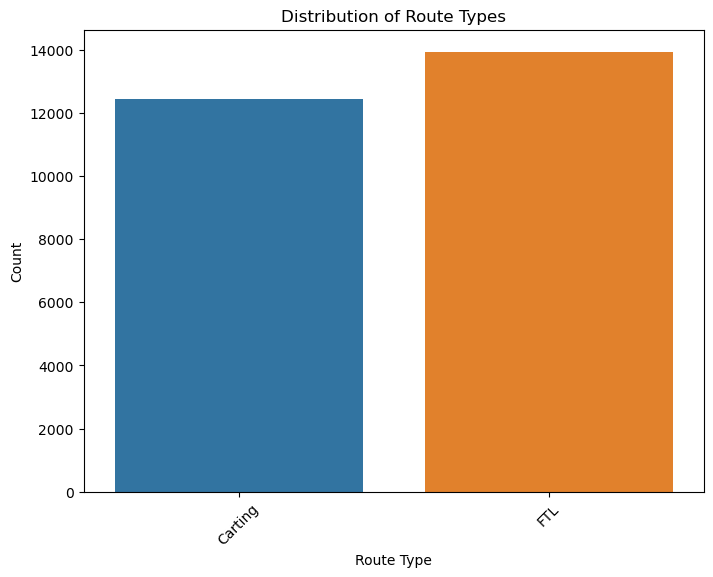

In [132]:
# Get the value counts of 'route_type' and convert to a DataFrame for plotting
route_type_counts = data_agg['route_type'].value_counts().reset_index()
route_type_counts.columns = ['route_type', 'count']
plt.figure(figsize=(8, 6))
sns.barplot(x='route_type', y='count', data=route_type_counts)
plt.title('Distribution of Route Types')
plt.xlabel('Route Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


### In-Depth Analysis

#### a. Hypothesis Testing

##### 1. Performing an in-depth analysis of the difference between trip_time (od_end_time - od_start_time) and start_scan_to_end_scan can uncover discrepancies and insights into operational efficiency, delays, or other factors affecting trip durations.

In [133]:
data_agg_final['time_difference'] = data_agg_final['trip_time'] - data_agg_final['start_scan_to_end_scan']


In [134]:
from scipy.stats import ttest_rel

# Assume `trip_time` and `start_scan_to_end_scan` are columns in your DataFrame
trip_time = data_agg_final['trip_time']
start_scan_to_end_scan = data_agg_final['start_scan_to_end_scan']

# Perform an independent two-sample t-test
t_stat, p_value = ttest_rel(trip_time, start_scan_to_end_scan)  

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is no significant difference between trip_time and start_scan_to_end_scan.")
else:
    print("There is a significant difference between trip_time and start_scan_to_end_scan.")


T-statistic: 211.45552116016256
P-value: 0.0
There is no significant difference between trip_time and start_scan_to_end_scan.


**Interpretation:**  
The p-value of 0.0 strongly rejects the null hypothesis, indicating that `trip_time` and `start_scan_to_end_scan` are closely related with no significant difference between them. This suggests that the scanning system’s times align well with actual trip durations.

### Business Implications:

1. **Operational Efficiency:**  
   The close correlation between scanning and trip times suggests the system is accurately reflecting real-world travel times, indicating efficient operations.

2. **System Accuracy:**  
   No significant difference means the system is functioning well, with minimal lag or discrepancies, boosting confidence in data used for decision-making.

3. **Decision-Making Confidence:**  
   With aligned metrics, predictive modeling and analysis based on trip times can be trusted, supporting better route planning and resource allocation.

4. **Resource Allocation:**  
   Operational resources can be managed effectively without concern for discrepancies, leading to potential cost savings.

5. **System Design Improvement:**  
   The alignment suggests further opportunities for automation, reducing manual intervention and improving productivity.

### Conclusion:  
The close alignment between scanning times and actual trip durations indicates an efficient, reliable system, enabling confident decision-making for future operations.ent, and process optimization.ent, and process optimization.

#### 2. Do hypothesis testing/ visual analysis between actual_time aggregated value and OSRM time aggregated value (aggregated values are the values you’ll get after merging the rows on the basis of trip_uuid)

In [135]:
# Perform the paired t-test
actual_time=data_agg_final['actual_time']
osrm_time=data_agg_final['osrm_time']
t_stat, p_value = ttest_rel(actual_time, osrm_time)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is a significant difference between actual_time and OSRM time.")
else:
    print("There is no significant difference between actual_time and OSRM time.")


T-statistic: 30.484284451190124
P-value: 5.16625811913629e-198
There is a significant difference between actual_time and OSRM time.


In [136]:
# Perform the paired t-test
t_stat, p_value_two_tailed = ttest_rel(actual_time, osrm_time)

# Convert the two-tailed p-value to a one-tailed p-value
p_value_one_tailed = p_value_two_tailed / 2

In [137]:
# Check if t_stat supports the one-tailed hypothesis
if t_stat > 0 and p_value_one_tailed < 0.05:
    print(f"T-statistic: {t_stat}")
    print(f"P-value (one-tailed): {p_value_one_tailed}")
    print("Conclusion: Actual time is significantly greater than OSRM time.")
else:
    print(f"T-statistic: {t_stat}")
    print(f"P-value (one-tailed): {p_value_one_tailed}")
    print("Conclusion: Actual time is not significantly greater than OSRM time.")

T-statistic: 30.484284451190124
P-value (one-tailed): 2.583129059568145e-198
Conclusion: Actual time is significantly greater than OSRM time.


There is a significant difference between actual_time and osrm_time:

It could indicate that the OSRM time predictions are consistently inaccurate or systematically biased.
Investigate the reasons for the difference (e.g., traffic, incorrect modeling assumptions, or real-world delays).

**Business Implications:**

**Inefficient Time Estimation:**  
OSRM underestimates trip times, affecting operational planning and customer expectations.

**Potential Causes:**  
- **Traffic/Road Conditions:** OSRM may not consider real-time variables like congestion or road closures.  
- **Operational Delays:** Internal delays (e.g., loading/unloading, scanning) can increase actual trip times.  
- **Outdated Models:** OSRM’s static data may not reflect dynamic road conditions.

**Impact on Business:**  
- **Customer Dissatisfaction:** Inaccurate delivery times lead to complaints and loss of trust.  
- **Inefficient Planning:** Misalignment between estimated and actual times disrupts schedules and resource allocation.

**Actionable Insights:**  
- **Improve Time Models:** Integrate real-time traffic and weather data.  
- **Optimize Internal Processes:** Identify and resolve internal delays.  
- **Set Realistic Expectations:** Provide buffer time to manage customer expectations.

**Performance Tracking:**  
- Track actual vs. estimated times by region, route, and time of day.  
- Focus on areas with the largest discrepancies for targeted improvements.  

This analysis highlights the need to align predictions with actual delivery times to optimize logistics and improvens or further analysis!

#### 3. Do hypothesis testing/ visual analysis between actual_time aggregated value and segment actual time aggregated value (aggregated values are the values you’ll get after merging the rows on the basis of trip_uuid)

In [138]:
actual_time = data_agg_final['actual_time']
segment_actual_time = data_agg_final['segment_actual_time']
# Perform paired t-test
t_stat, p_value = ttest_rel(actual_time, segment_actual_time)
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")
# Interpretation
if p_value < 0.05:
    print("There is a significant difference between actual time and segment actual time.")
else:
    print("There is no significant difference between actual time and segment actual time.")

T-statistic: -52.29366907171779
P-value: 0.0
There is a significant difference between actual time and segment actual time.


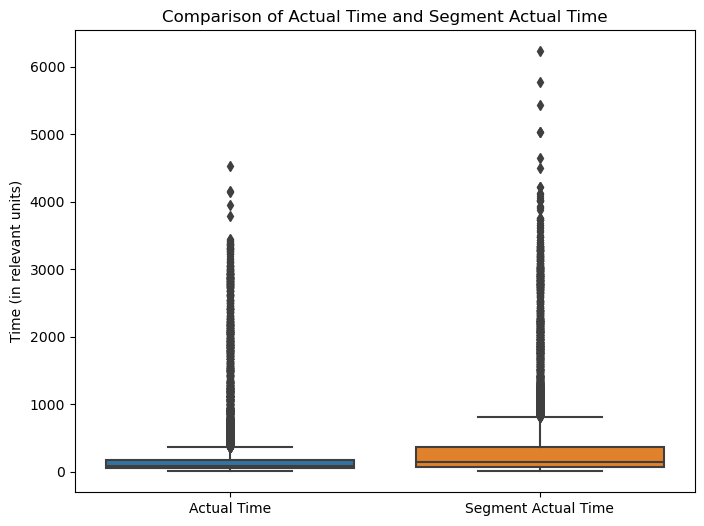

In [139]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=data_agg_final[['actual_time', 'segment_actual_time']])
plt.title("Comparison of Actual Time and Segment Actual Time")
plt.ylabel("Time (in relevant units)")
plt.xticks([0, 1], ['Actual Time', 'Segment Actual Time'])
plt.show()


### Business Implications

**Discrepancy in Aggregated Times:**  
The significant difference indicates that the total `actual_time` for trips is less than the sum of `segment_actual_time`, which may suggest:

- **Overestimation of segment times**: Segment times may be consistently higher than actual trip times.
- **Inefficiency in data aggregation**: Redundant or overlapping segments could be inflating segment totals.

**Operational Concerns:**  
- **Measurement or recording errors**: Segment time recording methods may need review.
- **Route optimization opportunities**: Longer segment times may point to inefficiencies in route planning.
- **Disjointed operations**: The discrepancy may indicate operational delays or gaps between segments.

### Actionable Recommendations:
- **Audit segment time recording**: Review and align segment time methodology with actual trip times.
- **Optimize segment transitions**: Investigate delays during transitions between segments.
- **Analyze specific routes**: Identify patterns in routes with consistent segment time deviations.

#### 4. Do hypothesis testing/ visual analysis between osrm distance aggregated value and segment osrm distance aggregated value (aggregated values are the values you’ll get after merging the rows on the basis of trip_uuid)

In [140]:
t_stat, p_value = ttest_rel(data_agg_final['osrm_distance'], data_agg_final['segment_osrm_distance'])

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("There is a significant difference between OSRM Distance and Segment OSRM Distance.")
else:
    print("There is no significant difference between OSRM Distance and Segment OSRM Distance.")


T-statistic: -50.905236847779406
P-value: 0.0
There is a significant difference between OSRM Distance and Segment OSRM Distance.


### Potential Real-World Implications

**Accuracy Discrepancy:**  
OSRM's aggregated trip distance may underestimate the total distance compared to the sum of segment distances, possibly due to simplifications in route optimization.

**Operational Planning:**  
Underestimations in OSRM Distance could lead to poor route planning, inefficiencies, and delays in delivery or logistics.

**Systematic Underestimation:**  
Consistent differences suggest flaws in how OSRM calculates aggregated distances, possibly neglecting overlaps or complexities in full trip routes.

**Potential Business Costs:**  
Underestimated distances could lead to revenue losses or inefficiencies in billing, fuel estimation, and resource allocation.

### Recommendations
- **Review OSRM Calculation Logic:** Investigate why OSRM Distance differs from Segment OSRM Distance and adjust methodology if needed.
- **Adopt Segment-Based Distance:** Use Segment OSRM Distance for more accurate trip analysis and planning.
- **Further Validation:** Analyze additional datasets to check if the discrepancy is consistent across trips or specific to certain routes.
- **Update Business Models:** Adjust logistics and cost models to account for potential underestimation of distances by OSRM.

Addressing these issues can improve route planning, reduce inefficiencies, and enhance customer satisfaction.

#### 4. Do hypothesis testing/ visual analysis between osrm time aggregated value and segment osrm time aggregated value (aggregated values are the values you’ll get after merging the rows on the basis of trip_uuid)

In [141]:
osrm_time = data_agg_final['osrm_time']
segment_osrm_time = data_agg_final['segment_osrm_time']
# Paired t-test
t_stat, p_value = ttest_rel(osrm_time, segment_osrm_time)
# Print results
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")
# Conclusion
alpha = 0.05  # Significance level
if p_value < alpha:
    print("There is a significant difference between OSRM time and Segment OSRM time.")
else:
    print("There is no significant difference between OSRM time and Segment OSRM time.")


T-statistic: -43.37186612146427
P-value: 0.0
There is a significant difference between OSRM time and Segment OSRM time.


Possible Reasons:
Data Discrepancies: Segment OSRM time might include additional delays or inefficiencies not reflected in the overall OSRM time.
Aggregation Effects: Errors or assumptions in aggregating segment times to derive the overall trip time could introduce discrepancies.
Routing Algorithms: Differences in the way OSRM calculates time for a complete trip versus individual segments.
Business Implications:
Performance Insights:

Highlight potential inefficiencies in segment-based routing or data recording processes.
May indicate overestimation of travel times at the segment level.
Operational Improvements:

Investigate segment-specific delays or anomalies.
Refine routing algorithms to align segment and overall trip time estimates more closely.

### Encoding Categorical Features

In [142]:
data_agg['route_type'].value_counts()

route_type
FTL        13939
Carting    12429
Name: count, dtype: int64

In [143]:
data_encoded = pd.get_dummies(data_agg_final, columns=['route_type'], prefix='route', drop_first=False)

In [144]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14817 entries, 0 to 14816
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   trip_uuid                       14817 non-null  object 
 1   source_center                   14817 non-null  object 
 2   destination_center              14817 non-null  object 
 3   start_scan_to_end_scan          14817 non-null  float64
 4   actual_distance_to_destination  14817 non-null  float64
 5   actual_time                     14817 non-null  float64
 6   osrm_time                       14817 non-null  float64
 7   osrm_distance                   14817 non-null  float64
 8   segment_actual_time             14817 non-null  float64
 9   segment_osrm_time               14817 non-null  float64
 10  segment_osrm_distance           14817 non-null  float64
 11  source_city                     14817 non-null  object 
 12  source_place                    

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# List of columns to encode
columns_to_encode = ['source_city', 'source_place', 'source_state', 
                     'destination_city', 'destination_place', 'destination_state']

for col in columns_to_encode:
    # Handle NaN values before encoding
    data[col] = data[col].fillna('Unknown')
    data[col] = label_encoder.fit_transform(data[col])


In [145]:
data_encoded.drop(columns=['time_difference'],inplace=True)

#### Normalize and Standardize Numerical Features

In [146]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [147]:
# List of numerical columns
numerical_features = [
    'start_scan_to_end_scan', 
    'actual_distance_to_destination', 
    'actual_time', 
    'osrm_time', 
    'osrm_distance', 
    'segment_actual_time', 
    'segment_osrm_time', 
    'segment_osrm_distance', 
    'trip_time']

In [148]:
data_scaled=data_encoded.copy()

In [149]:
scaler=MinMaxScaler()
data_scaled[numerical_features]=scaler.fit_transform(data_scaled[numerical_features])

In [150]:
data_scaled.head()

,trip_uuid,source_center,destination_center,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,...,source_state,destination_city,destination_place,destination_state,trip_year,trip_month,trip_day,trip_time,route_Carting,route_FTL
0,trip-153671041653548748,IND209304AAA,IND000000ACB,0.157186,0.225167,0.159850,0.350938,0.231204,0.247388,0.391712,...,Uttar Pradesh,Gurgaon,Bilaspur,Haryana,2018,9,12,0.157145,False,True
1,trip-153671042288605164,IND561203AAB,IND562101AAA,0.004571,0.020611,0.008402,0.030602,0.020646,0.021218,0.023065,...,Karnataka,Chikblapur,ShntiSgr,Karnataka,2018,9,12,0.004550,True,False
2,trip-153671043369099517,IND000000ACB,IND160002AAC,0.103098,0.876211,0.133098,0.855874,0.890665,0.530301,0.756450,...,Haryana,Chandigarh,Mehmdpur,Punjab,2018,9,12,0.103058,False,True
3,trip-153671046011330457,IND400072AAB,IND401104AAA,0.009904,0.004260,0.011055,0.004442,0.004578,0.008037,0.003909,...,Maharashtra,Mumbai,MiraRd,Maharashtra,2018,9,12,0.009840,True,False
4,trip-153671052974046625,IND583101AAA,IND583201AAA,0.016506,0.009173,0.030511,0.054788,0.008846,0.053207,0.042611,...,Karnataka,Hospet,Dc,Karnataka,2018,9,12,0.016382,False,True


### Outlier Detection and Handling

Let's start with the following numerical columns based on the provided dataset structure:

start_scan_to_end_scan

actual_distance_to_destination

actual_time

osrm_time

osrm_distance

We will use statistical methods (like the IQR method) and visualizations such as box plots or histograms to check for outliers.

We will use the data_encoded dataframe for the outlier handling.

In [151]:
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14817 entries, 0 to 14816
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   trip_uuid                       14817 non-null  object 
 1   source_center                   14817 non-null  object 
 2   destination_center              14817 non-null  object 
 3   start_scan_to_end_scan          14817 non-null  float64
 4   actual_distance_to_destination  14817 non-null  float64
 5   actual_time                     14817 non-null  float64
 6   osrm_time                       14817 non-null  float64
 7   osrm_distance                   14817 non-null  float64
 8   segment_actual_time             14817 non-null  float64
 9   segment_osrm_time               14817 non-null  float64
 10  segment_osrm_distance           14817 non-null  float64
 11  source_city                     14817 non-null  object 
 12  source_place                    

When the numerical features like start_scan_to_end_scan, actual_distance_to_destination, actual_time, osrm_time, and osrm_distance are expected to depend on the combination of source_city and destination_city, directly applying outlier detection on each feature across the entire dataset could result in misleading conclusions. The outlier detection should instead take into account the different combinations of source_city and destination_city, as the values for these features might vary significantly based on the pairings.

Correct Approach: Outlier Detection by Group

The right way to approach this is to group the data by source_city and destination_city (or any other relevant combination like source_state and destination_state), and then apply the outlier detection methods within each group. This ensures that the values are compared in a context-sensitive manner, considering the variation across different source-destination pairs.

In [152]:
numerical_features = ['start_scan_to_end_scan', 
                      'actual_distance_to_destination', 
                      'actual_time', 
                      'osrm_time', 
                      'osrm_distance']

In [153]:
grouped_data = data_encoded.groupby(['source_state', 'destination_state'])

In [154]:
def detect_outliers_iqr_grouped(group, numerical_features):
    outliers = {}
    for feature in numerical_features:
        # Calculate Q1, Q3, and IQR for the group
        Q1 = group[feature].quantile(0.25)
        Q3 = group[feature].quantile(0.75)
        IQR = Q3 - Q1
        # Define lower and upper bounds for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Get indices of outliers (values outside the bounds)
        outliers[feature] = group[(group[feature] < lower_bound) | (group[feature] > upper_bound)].index.tolist()
    return outliers

In [155]:
outliers_by_group = {}
for name, group in grouped_data:
    outliers_by_group[name] = detect_outliers_iqr_grouped(group, numerical_features)

In [156]:
for group_name, outliers in outliers_by_group.items():
    print(f"Outliers for source-destination pair: {group_name}")
    for feature, indices in outliers.items():
        print(f"{feature}: {len(indices)} outliers")

Outliers for source-destination pair: ('Andhra Pradesh', 'Andhra Pradesh')
start_scan_to_end_scan: 21 outliers
actual_distance_to_destination: 3 outliers
actual_time: 25 outliers
osrm_time: 11 outliers
osrm_distance: 2 outliers
Outliers for source-destination pair: ('Andhra Pradesh', 'Karnataka')
start_scan_to_end_scan: 0 outliers
actual_distance_to_destination: 0 outliers
actual_time: 0 outliers
osrm_time: 0 outliers
osrm_distance: 0 outliers
Outliers for source-destination pair: ('Andhra Pradesh', 'Orissa')
start_scan_to_end_scan: 3 outliers
actual_distance_to_destination: 0 outliers
actual_time: 1 outliers
osrm_time: 0 outliers
osrm_distance: 0 outliers
Outliers for source-destination pair: ('Andhra Pradesh', 'Telangana')
start_scan_to_end_scan: 1 outliers
actual_distance_to_destination: 0 outliers
actual_time: 0 outliers
osrm_time: 18 outliers
osrm_distance: 1 outliers
Outliers for source-destination pair: ('Andhra Pradesh', 'Uttar Pradesh')
start_scan_to_end_scan: 0 outliers
actua

We will try to check the outliers for above mentioned numerical features for source_state as Maharashtra and destination_state as Karnataka. In the same way we can check for other states too.

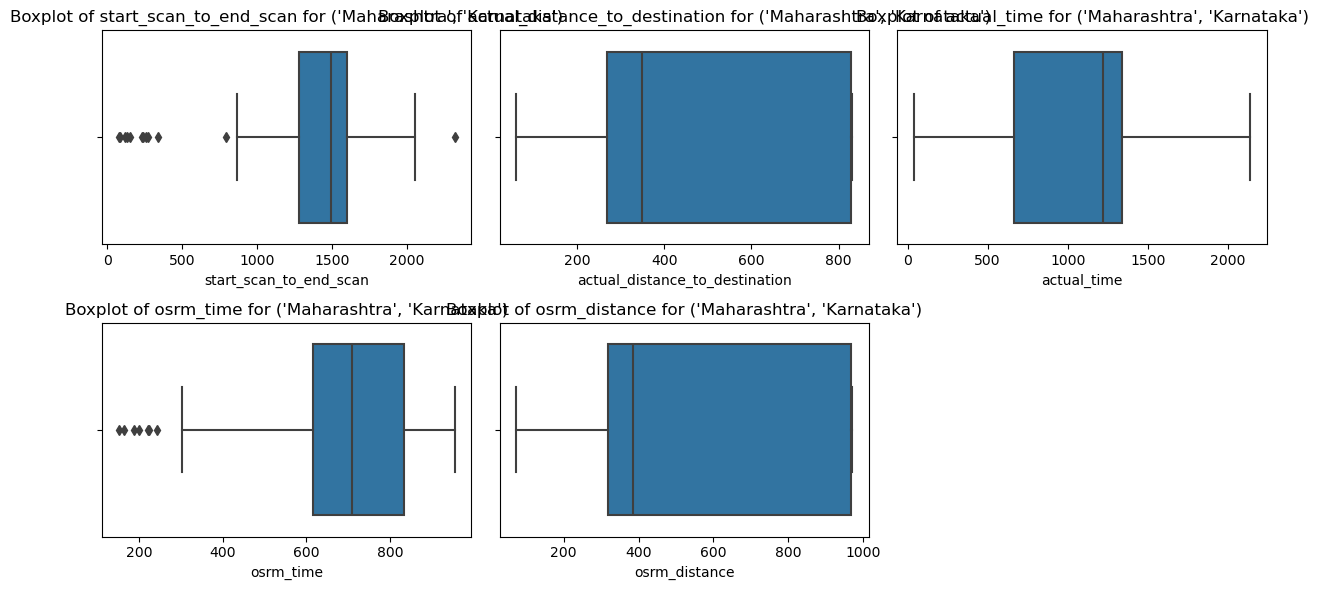

In [157]:
specific_group = ('Maharashtra', 'Karnataka')  # Replace with the pair you're interested in
specific_group_data = data_encoded[(data_encoded['source_state'] == specific_group[0]) & 
                           (data_encoded['destination_state'] == specific_group[1])]

plt.figure(figsize=(12, 6))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=specific_group_data[feature])
    plt.title(f'Boxplot of {feature} for {specific_group}')
plt.tight_layout()
plt.show()

#### Removal of Outliers from the dataset

In [158]:
# Create a list of indices that correspond to outliers
outlier_indices = []
for group_name, outliers in outliers_by_group.items():
    for feature, indices in outliers.items():
        outlier_indices.extend(indices)

In [159]:
# Remove the outliers from the original data
data_encoded_cleaned = data_encoded.drop(outlier_indices, axis=0)
data_encoded_cleaned.reset_index(drop=True, inplace=True)

In [160]:
data_encoded_cleaned

,trip_uuid,source_center,destination_center,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,...,source_state,destination_city,destination_place,destination_state,trip_year,trip_month,trip_day,trip_time,route_Carting,route_FTL
0,trip-153671041653548748,IND209304AAA,IND000000ACB,1260.0,440.973689,732.0,717.0,544.8027,1548.0,1008.0,...,Uttar Pradesh,Gurgaon,Bilaspur,Haryana,2018,9,12,1260.604421,False,True
1,trip-153671042288605164,IND561203AAB,IND562101AAA,58.0,48.542890,47.0,68.0,56.9116,141.0,65.0,...,Karnataka,Chikblapur,ShntiSgr,Karnataka,2018,9,12,58.832388,True,False
2,trip-153671043369099517,IND000000ACB,IND160002AAC,834.0,1689.964663,611.0,1740.0,2072.8556,3308.0,1941.0,...,Haryana,Chandigarh,Mehmdpur,Punjab,2018,9,12,834.638929,False,True
3,trip-153671046011330457,IND400072AAB,IND401104AAA,100.0,17.175274,59.0,15.0,19.6800,59.0,16.0,...,Maharashtra,Mumbai,MiraRd,Maharashtra,2018,9,12,100.494935,True,False
4,trip-153671055416136166,IND600056AAA,IND602105AAB,60.0,9.271519,40.0,23.0,11.8422,60.0,23.0,...,Tamil Nadu,Chennai,Sriperumbudur,Tamil Nadu,2018,9,12,60.877949,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12042,trip-153861091843037040,IND400072AAB,IND401104AAA,88.0,17.760248,38.0,16.0,20.5065,37.0,16.0,...,Maharashtra,Mumbai,MiraRd,Maharashtra,2018,10,3,88.215987,True,False
12043,trip-153861095625827784,IND160002AAC,IND140603AAA,152.0,31.261599,34.0,62.0,44.5639,82.0,62.0,...,Punjab,Zirakpur,DC,Punjab,2018,10,3,152.787843,True,False
12044,trip-153861104386292051,IND121004AAB,IND121004AAA,60.0,15.513784,21.0,12.0,16.0882,21.0,11.0,...,Haryana,Faridabad,Blbgarh,Haryana,2018,10,3,60.590521,True,False
12045,trip-153861106442901555,IND208006AAA,IND209304AAA,248.0,19.335831,190.0,48.0,28.8492,281.0,88.0,...,Uttar Pradesh,Central,H,Uttar Pradesh,2018,10,3,248.409092,True,False


In [161]:
# List of numerical columns
numerical_features_1 = [
    'start_scan_to_end_scan', 
    'actual_distance_to_destination', 
    'actual_time', 
    'osrm_time', 
    'osrm_distance', 
    'segment_actual_time', 
    'segment_osrm_time', 
    'segment_osrm_distance', 
    'trip_time']

In [162]:
data_scaled_cleaned=data_encoded_cleaned.copy()

In [163]:
scaler=MinMaxScaler()
data_scaled_cleaned[numerical_features]=scaler.fit_transform(data_scaled_cleaned[numerical_features])

In [164]:
data_scaled_cleaned

,trip_uuid,source_center,destination_center,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,...,source_state,destination_city,destination_place,destination_state,trip_year,trip_month,trip_day,trip_time,route_Carting,route_FTL
0,trip-153671041653548748,IND209304AAA,IND000000ACB,0.157186,0.225167,0.191523,0.350617,0.231204,1548.0,1008.0,...,Uttar Pradesh,Gurgaon,Bilaspur,Haryana,2018,9,12,1260.604421,False,True
1,trip-153671042288605164,IND561203AAB,IND562101AAA,0.004571,0.020611,0.010066,0.030123,0.020646,141.0,65.0,...,Karnataka,Chikblapur,ShntiSgr,Karnataka,2018,9,12,58.832388,True,False
2,trip-153671043369099517,IND000000ACB,IND160002AAC,0.103098,0.876211,0.159470,0.855802,0.890665,3308.0,1941.0,...,Haryana,Chandigarh,Mehmdpur,Punjab,2018,9,12,834.638929,False,True
3,trip-153671046011330457,IND400072AAB,IND401104AAA,0.009904,0.004260,0.013245,0.003951,0.004578,59.0,16.0,...,Maharashtra,Mumbai,MiraRd,Maharashtra,2018,9,12,100.494935,True,False
4,trip-153671055416136166,IND600056AAA,IND602105AAB,0.004825,0.000140,0.008212,0.007901,0.001195,60.0,23.0,...,Tamil Nadu,Chennai,Sriperumbudur,Tamil Nadu,2018,9,12,60.877949,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12042,trip-153861091843037040,IND400072AAB,IND401104AAA,0.008380,0.004565,0.007682,0.004444,0.004934,37.0,16.0,...,Maharashtra,Mumbai,MiraRd,Maharashtra,2018,10,3,88.215987,True,False
12043,trip-153861095625827784,IND160002AAC,IND140603AAA,0.016506,0.011603,0.006623,0.027160,0.015317,82.0,62.0,...,Punjab,Zirakpur,DC,Punjab,2018,10,3,152.787843,True,False
12044,trip-153861104386292051,IND121004AAB,IND121004AAA,0.004825,0.003394,0.003179,0.002469,0.003028,21.0,11.0,...,Haryana,Faridabad,Blbgarh,Haryana,2018,10,3,60.590521,True,False
12045,trip-153861106442901555,IND208006AAA,IND209304AAA,0.028695,0.005386,0.047947,0.020247,0.008535,281.0,88.0,...,Uttar Pradesh,Central,H,Uttar Pradesh,2018,10,3,248.409092,True,False


In [165]:
# Replace True/False with 1/0 in the specified columns
data_scaled_cleaned['route_Carting'] = data_scaled_cleaned['route_Carting'].astype(int)
data_scaled_cleaned['route_FTL'] = data_scaled_cleaned['route_FTL'].astype(int)
data_scaled_cleaned[['route_Carting', 'route_FTL']].head()


,route_Carting,route_FTL
0,0,1
1,1,0
2,0,1
3,1,0
4,1,0


In [166]:
delhivery_final = data_scaled_cleaned.copy()

#### delhivery_final is the final dataset that we got after performing feature engineering, aggregations, feature creation, encoding, scaling and outliers removal. This dataset can be used by Data science team to create predictive modelling. 

#### The jupyter notebook contains dataframes achieved at every step mentioned above so as to make convenient to work on any step if it is necessary.

1. **Short Distance (0–10 km)**:
   - Short-distance deliveries (0–10 km) are typically local shipments, focused on last-mile delivery within city limits.

2. **Medium Distance (10–50 km)**:
   - Medium-distance deliveries (10–50 km) cover suburban areas and are often used for city-to-town shipments.

3. **Long Distance (50–150 km)**:
   - Long-distance deliveries (50–150 km) involve inter-city transport, commonly for shipments between major urban areas.

4. **Very Long Distance (150+ km)**:
   - Very long-distance deliveries (150+ km) are for cross-state or national logistics, connecting distant regions.

In [167]:
def categorize_distance(distance):
    if distance <= 10:
        return 'Short'
    elif 10 < distance <= 50:
        return 'Medium'
    elif 50 < distance <= 150:
        return 'Long'
    else:
        return 'High'

# Apply the categorization
delhivery_final['distance_category'] = delhivery_final['actual_distance_to_destination'].apply(categorize_distance)



In [168]:
#delhivery_final.to_csv('delhivery_final.csv', index=False)

#### Recommendations :


#### 1. **Improve Route Planning**
- **Observation**: Significant discrepancies exist between OSRM (Open Source Routing Machine) times/distances and actual trip data, indicating potential inefficiencies in routes.
- **Action Item**: Re-evaluate and optimize routes using actual trip data to minimize discrepancies and reduce delays.

---

#### 2. **Focus on Segment-Level Analysis**
- **Observation**: Aggregated and segment-level data for time and distance show significant differences, pointing to potential inefficiencies in specific segments.
- **Action Item**: Identify and address delays or inefficiencies in frequently problematic segments.

---

#### 3. **Address Overestimated Trip Times**
- **Observation**: Actual trip times are consistently higher than OSRM-estimated times, suggesting trips are taking longer than planned.
- **Action Item**: Investigate delays caused by traffic, driver behavior, or loading/unloading processes, and implement measures to improve punctuality.

---

#### 4. **Monitor and Update Distance Metrics**
- **Observation**: Variations between aggregated and segment OSRM distances indicate potential inaccuracies in distance tracking.
- **Action Item**: Conduct regular audits of distance data and ensure accurate GPS tracking systems for all trips.

---

#### 5. **Enhance Data Collection Accuracy**
- **Observation**: Discrepancies in metrics suggest inconsistencies in data collection or logging methods.
- **Action Item**: Standardize and automate data collection processes to improve consistency and reliability.

---

#### 6. **Driver and Fleet Performance Reviews**
- **Observation**: Inefficiencies may result from individual driver behaviors or vehicle performance differences.
- **Action Item**: Implement regular driver training programs and perform vehicle maintenance checks to boost performance.

---

#### 7. **Revisit Delivery Timelines**
- **Observation**: Higher-than-expected actual trip times can negatively impact customer satisfaction and increase operational costs.
- **Action Item**: Adjust delivery timelines based on realistic estimates from historical data to better align with customer expectations.

---

#### 8. **Investigate Specific Routes**
- **Observation**: Frequent discrepancies between city pairs highlight potential bottlenecks on certain routes.
- **Action Item**: Prioritize resolving recurring issues in frequently delayed city-to-city combinations.

In [169]:
delhivery_final

,trip_uuid,source_center,destination_center,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,...,destination_city,destination_place,destination_state,trip_year,trip_month,trip_day,trip_time,route_Carting,route_FTL,distance_category
0,trip-153671041653548748,IND209304AAA,IND000000ACB,0.157186,0.225167,0.191523,0.350617,0.231204,1548.0,1008.0,...,Gurgaon,Bilaspur,Haryana,2018,9,12,1260.604421,0,1,Short
1,trip-153671042288605164,IND561203AAB,IND562101AAA,0.004571,0.020611,0.010066,0.030123,0.020646,141.0,65.0,...,Chikblapur,ShntiSgr,Karnataka,2018,9,12,58.832388,1,0,Short
2,trip-153671043369099517,IND000000ACB,IND160002AAC,0.103098,0.876211,0.159470,0.855802,0.890665,3308.0,1941.0,...,Chandigarh,Mehmdpur,Punjab,2018,9,12,834.638929,0,1,Short
3,trip-153671046011330457,IND400072AAB,IND401104AAA,0.009904,0.004260,0.013245,0.003951,0.004578,59.0,16.0,...,Mumbai,MiraRd,Maharashtra,2018,9,12,100.494935,1,0,Short
4,trip-153671055416136166,IND600056AAA,IND602105AAB,0.004825,0.000140,0.008212,0.007901,0.001195,60.0,23.0,...,Chennai,Sriperumbudur,Tamil Nadu,2018,9,12,60.877949,1,0,Short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12042,trip-153861091843037040,IND400072AAB,IND401104AAA,0.008380,0.004565,0.007682,0.004444,0.004934,37.0,16.0,...,Mumbai,MiraRd,Maharashtra,2018,10,3,88.215987,1,0,Short
12043,trip-153861095625827784,IND160002AAC,IND140603AAA,0.016506,0.011603,0.006623,0.027160,0.015317,82.0,62.0,...,Zirakpur,DC,Punjab,2018,10,3,152.787843,1,0,Short
12044,trip-153861104386292051,IND121004AAB,IND121004AAA,0.004825,0.003394,0.003179,0.002469,0.003028,21.0,11.0,...,Faridabad,Blbgarh,Haryana,2018,10,3,60.590521,1,0,Short
12045,trip-153861106442901555,IND208006AAA,IND209304AAA,0.028695,0.005386,0.047947,0.020247,0.008535,281.0,88.0,...,Central,H,Uttar Pradesh,2018,10,3,248.409092,1,0,Short


In [170]:
delhivery_final.drop(columns=['source_place','destination_place','trip_year','source_center','destination_center','trip_time'],inplace=True)

In [171]:
delhivery_final

,trip_uuid,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,source_city,source_state,destination_city,destination_state,trip_month,trip_day,route_Carting,route_FTL,distance_category
0,trip-153671041653548748,0.157186,0.225167,0.191523,0.350617,0.231204,1548.0,1008.0,1320.4733,Central,Uttar Pradesh,Gurgaon,Haryana,9,12,0,1,Short
1,trip-153671042288605164,0.004571,0.020611,0.010066,0.030123,0.020646,141.0,65.0,84.1894,Doddablpur,Karnataka,Chikblapur,Karnataka,9,12,1,0,Short
2,trip-153671043369099517,0.103098,0.876211,0.159470,0.855802,0.890665,3308.0,1941.0,2545.2678,Gurgaon,Haryana,Chandigarh,Punjab,9,12,0,1,Short
3,trip-153671046011330457,0.009904,0.004260,0.013245,0.003951,0.004578,59.0,16.0,19.8766,Mumbai Hub,Maharashtra,Mumbai,Maharashtra,9,12,1,0,Short
4,trip-153671055416136166,0.004825,0.000140,0.008212,0.007901,0.001195,60.0,23.0,28.0647,Chennai,Tamil Nadu,Chennai,Tamil Nadu,9,12,1,0,Short
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12042,trip-153861091843037040,0.008380,0.004565,0.007682,0.004444,0.004934,37.0,16.0,20.5065,Mumbai Hub,Maharashtra,Mumbai,Maharashtra,10,3,1,0,Short
12043,trip-153861095625827784,0.016506,0.011603,0.006623,0.027160,0.015317,82.0,62.0,64.8551,Chandigarh,Punjab,Zirakpur,Punjab,10,3,1,0,Short
12044,trip-153861104386292051,0.004825,0.003394,0.003179,0.002469,0.003028,21.0,11.0,16.0883,FBD,Haryana,Faridabad,Haryana,10,3,1,0,Short
12045,trip-153861106442901555,0.028695,0.005386,0.047947,0.020247,0.008535,281.0,88.0,104.8866,Kanpur,Uttar Pradesh,Central,Uttar Pradesh,10,3,1,0,Short


In [172]:
delhivery_final.iloc[0]

trip_uuid                         trip-153671041653548748
start_scan_to_end_scan                           0.157186
actual_distance_to_destination                   0.225167
actual_time                                      0.191523
osrm_time                                        0.350617
osrm_distance                                    0.231204
segment_actual_time                                1548.0
segment_osrm_time                                  1008.0
segment_osrm_distance                           1320.4733
source_city                                       Central
source_state                                Uttar Pradesh
destination_city                                  Gurgaon
destination_state                                 Haryana
trip_month                                              9
trip_day                                               12
route_Carting                                           0
route_FTL                                               1
distance_categ

In [173]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Initialize LabelEncoder
label_encoders = {}
categorical_columns = ['source_city', 'source_state', 'destination_city', 'destination_state', 'distance_category']

# Label Encode categorical columns
for col in categorical_columns:
    le = LabelEncoder()
    delhivery_final[col] = le.fit_transform(delhivery_final[col])  # Correctly passing the column
    label_encoders[col] = le  # Store encoder for inverse transform if needed later
# Initialize StandardScaler
scaler = StandardScaler()
# Columns to scale
numerical_columns = ['segment_actual_time', 'segment_osrm_distance', 'segment_osrm_time']
# Scale numerical columns
delhivery_final[numerical_columns] = scaler.fit_transform(delhivery_final[numerical_columns])

In [174]:
delhivery_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12047 entries, 0 to 12046
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   trip_uuid                       12047 non-null  object 
 1   start_scan_to_end_scan          12047 non-null  float64
 2   actual_distance_to_destination  12047 non-null  float64
 3   actual_time                     12047 non-null  float64
 4   osrm_time                       12047 non-null  float64
 5   osrm_distance                   12047 non-null  float64
 6   segment_actual_time             12047 non-null  float64
 7   segment_osrm_time               12047 non-null  float64
 8   segment_osrm_distance           12047 non-null  float64
 9   source_city                     12047 non-null  int32  
 10  source_state                    12047 non-null  int32  
 11  destination_city                12047 non-null  int32  
 12  destination_state               

In [175]:
# Now we try to predict the actual_time taken for the trip.

In [176]:
delhivery_final.iloc[0]

trip_uuid                         trip-153671041653548748
start_scan_to_end_scan                           0.157186
actual_distance_to_destination                   0.225167
actual_time                                      0.191523
osrm_time                                        0.350617
osrm_distance                                    0.231204
segment_actual_time                              2.284189
segment_osrm_time                                2.684253
segment_osrm_distance                             2.68419
source_city                                           112
source_state                                           26
destination_city                                      226
destination_state                                      11
trip_month                                              9
trip_day                                               12
route_Carting                                           0
route_FTL                                               1
distance_categ

In [177]:
delhivery_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12047 entries, 0 to 12046
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   trip_uuid                       12047 non-null  object 
 1   start_scan_to_end_scan          12047 non-null  float64
 2   actual_distance_to_destination  12047 non-null  float64
 3   actual_time                     12047 non-null  float64
 4   osrm_time                       12047 non-null  float64
 5   osrm_distance                   12047 non-null  float64
 6   segment_actual_time             12047 non-null  float64
 7   segment_osrm_time               12047 non-null  float64
 8   segment_osrm_distance           12047 non-null  float64
 9   source_city                     12047 non-null  int32  
 10  source_state                    12047 non-null  int32  
 11  destination_city                12047 non-null  int32  
 12  destination_state               

In [178]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [179]:
X=delhivery_final.drop(columns=['trip_uuid','actual_time','distance_category'])

In [180]:
y=delhivery_final['actual_time'] # target variable

In [181]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [182]:
# Train the model
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [183]:
# Make predictions
y_pred = model.predict(X_test)

In [184]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)

In [185]:
mae

0.002818304525844301

In [186]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [187]:
rmse

0.007850918527000489

In [188]:
r2 = r2_score(y_test, y_pred)

In [189]:
r2

0.9950217964829635

In [190]:
print("Model Performance:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Square Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

Model Performance:
Mean Absolute Error (MAE): 0.002818304525844301
Root Mean Square Error (RMSE): 0.007850918527000489
R² Score: 0.9950217964829635


Mean Absolute Error (MAE): 0.0028 — This represents the average error in predicting the target variable, and a low value signifies that the predictions are very close to the actual values.
Root Mean Square Error (RMSE): 0.0079 — This metric gives more weight to larger errors, and the value is also impressively low.
R² Score: 0.9950 — This indicates that 99.5% of the variance in the target variable (actual_time) is explained by the model.

In [191]:
feature_importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
print(importance_df.sort_values(by='Importance', ascending=False))

                           Feature  Importance
0           start_scan_to_end_scan    0.971517
4              segment_actual_time    0.020677
3                    osrm_distance    0.001772
6            segment_osrm_distance    0.001447
1   actual_distance_to_destination    0.000929
5                segment_osrm_time    0.000749
2                        osrm_time    0.000726
10               destination_state    0.000578
9                 destination_city    0.000450
7                      source_city    0.000437
8                     source_state    0.000407
12                        trip_day    0.000251
13                   route_Carting    0.000029
14                       route_FTL    0.000017
11                      trip_month    0.000014


With an R² score of 0.995 and low errors (MAE and RMSE), your model seems to predict the target variable accurately. There's no need to over-engineer if the model is already serving its purpose effectively.

What You Can Do Next

Document Results: Create a clear report of your findings, including model performance, feature importance, and the implications of your insights.

Deploy the Model: If required, integrate the model into a production pipeline or system.

Monitor Performance: If the model will be used over time, ensure it is periodically evaluated on new data to check for any drop in performance (concept drift).

Archive the Project: Save the model, dataset, and code for future reference or re-use.

### Prediction of Distance Category :

While implementing feature engineering we had scaled the data including 'actual_distance_to_destination' feature and then created the feature distance_category. But,every distance_category came out to be 'short' due to scaling and categorization range mismacth. Hence, we will use 'data_encoded_cleaned' dataframe for further classification of distance('distance_category') prediction.

In [210]:
data_encoded_cleaned.to_csv('delhivery.csv', index=False)

In [211]:
delhivery_df=pd.read_csv('delhivery.csv')

In [212]:
# Step 1 : Separate features and target variables

In [213]:
delhivery_df

,trip_uuid,source_center,destination_center,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,...,source_state,destination_city,destination_place,destination_state,trip_year,trip_month,trip_day,trip_time,route_Carting,route_FTL
0,trip-153671041653548748,IND209304AAA,IND000000ACB,1260.0,440.973689,732.0,717.0,544.8027,1548.0,1008.0,...,Uttar Pradesh,Gurgaon,Bilaspur,Haryana,2018,9,12,1260.604421,False,True
1,trip-153671042288605164,IND561203AAB,IND562101AAA,58.0,48.542890,47.0,68.0,56.9116,141.0,65.0,...,Karnataka,Chikblapur,ShntiSgr,Karnataka,2018,9,12,58.832388,True,False
2,trip-153671043369099517,IND000000ACB,IND160002AAC,834.0,1689.964663,611.0,1740.0,2072.8556,3308.0,1941.0,...,Haryana,Chandigarh,Mehmdpur,Punjab,2018,9,12,834.638929,False,True
3,trip-153671046011330457,IND400072AAB,IND401104AAA,100.0,17.175274,59.0,15.0,19.6800,59.0,16.0,...,Maharashtra,Mumbai,MiraRd,Maharashtra,2018,9,12,100.494935,True,False
4,trip-153671055416136166,IND600056AAA,IND602105AAB,60.0,9.271519,40.0,23.0,11.8422,60.0,23.0,...,Tamil Nadu,Chennai,Sriperumbudur,Tamil Nadu,2018,9,12,60.877949,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12042,trip-153861091843037040,IND400072AAB,IND401104AAA,88.0,17.760248,38.0,16.0,20.5065,37.0,16.0,...,Maharashtra,Mumbai,MiraRd,Maharashtra,2018,10,3,88.215987,True,False
12043,trip-153861095625827784,IND160002AAC,IND140603AAA,152.0,31.261599,34.0,62.0,44.5639,82.0,62.0,...,Punjab,Zirakpur,DC,Punjab,2018,10,3,152.787843,True,False
12044,trip-153861104386292051,IND121004AAB,IND121004AAA,60.0,15.513784,21.0,12.0,16.0882,21.0,11.0,...,Haryana,Faridabad,Blbgarh,Haryana,2018,10,3,60.590521,True,False
12045,trip-153861106442901555,IND208006AAA,IND209304AAA,248.0,19.335831,190.0,48.0,28.8492,281.0,88.0,...,Uttar Pradesh,Central,H,Uttar Pradesh,2018,10,3,248.409092,True,False


In [204]:
# Step 1 : Prepare data

In [206]:
X_1=data.drop(columns=['trip_uuid','actual_time'])

In [208]:
y_1=data['distance_category']

In [196]:
# Step 2 : Handle class imbalance

In [209]:
data['distance_category'].value_counts()

distance_category
Short    12047
Name: count, dtype: int64